# Interrupted Time Series (ITS)

## Interrupted Time Series (ITS) Models

Interrupted Time Series (ITS) is a causal method for time series data that helps separate the effect of an intervention from ongoing trends.

## Motivating Example: E-commerce and Product Photos

A pet toy company invests in professional product photos right before Black Friday.

Sales rise after the photos are uploaded—but are the photos the cause, or just seasonal demand?

Averages before vs. after the intervention ignore pre-existing trends (e.g., the holiday shopping surge), which can lead to overestimating the intervention's effect.

## What ITS Does
- Models the pre-treatment trajectory to predict what would have happened without the intervention (the counterfactual).
- Compares observed post-treatment sales to that predicted baseline.
- The difference isolates the incremental causal effect of the intervention.

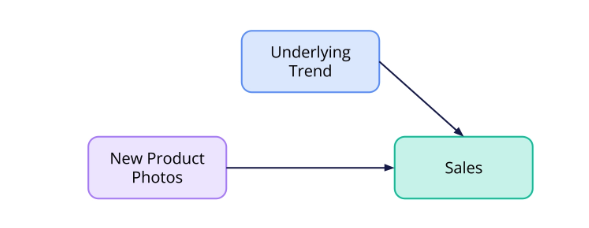

## Level vs. Trend Changes in Interrupted Time Series
When using an Interrupted Time Series (ITS) model, we look for two main effects:

- Level change: an immediate jump right after the intervention (e.g., sales spike the day new photos go live)
- Trend change: a shift in the growth rate that continues over time (e.g., more sustained sales growth)
  
Both effects can occur together or separately. Be cautious about extrapolating their implications too far—this can result in unrealistic outcomes (like conversion rates below 0% or above 100%).

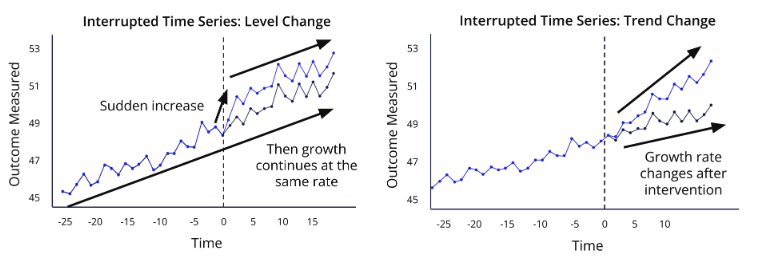

In summary: ITS models are structured to detect both immediate level shifts and changes in trend that begin at the intervention. By doing so, they help distinguish between short- and long-run effects.

## Regression Model for Interrupted Time Series
An Interrupted Time Series (ITS) model decomposes outcomes into baseline, trend, and post-intervention effects:

$Y_t = \beta_0 + \beta_1 \cdot Trend_t + \beta_2 \cdot Post_t + \beta_3 \cdot (Trend_t \times Post_t) + \varepsilon_t$

- $Y_t$: outcome variable
- $Trend_t$: time trend, frequently taking the value of 0 on the event date, -1 on the period before, +1 on the period after, and so on
- $Posts_t$: dummy variable that equals 0 before the intervention and 1 afterward
- $Trend_t \times Post_t$: interaction term that allows the post-intervention trend to differ from the pre-intervention trend
- $\beta_0$: baseline level of the outcome at time 0
- $\beta_1$: underlying pre-intervention trend
- $\beta_2$: immediate level shift after intervention
- $\beta_3$: trend change after intervention
- $\epsilon$: error term

## Python Implementation

We use `statsmodels.formula.api.ols` with variables:
- `trend` for $Trend_t$
- `post` for $Post_t$
- `trend:post` for $Trend_t \times Post_t$
  
We put those all together into a formula like this:

`sales ~ trend + post + trend:post`

## Interpretation
- The coef value for $post_t$ is $\beta_2$: If the corresponding p-value is significant, this indicates an immediate jump after the intervention
- The coef value for $trend_t:post_t$ is: If the corresponding p-value is significant, this indicates an altered growth rate after the intervention

Together, these coefficients quantify the causal impact of the intervention (e.g., professional photos) while accounting for the pre-existing upward trend.


## Exercise:

The following Interrupted Time Series (ITS) model is used to estimate the effect of an intervention that begins at time **t = 0**:

$
Y_t = \beta_0 + \beta_1 \cdot Trend_t + \beta_2 \cdot Post_t + \beta_3 \cdot (Trend_t \times Post_t) + \varepsilon_t
$

## Where:
- **Trend_t** is centered at the intervention and takes values like:  
  **-2, -1, 0, 1, 2**
- **Post_t** = 1 for all **t ≥ 0**, and 0 otherwise
- **β₂ = 10**, and **β₃ = 2**

---

## Question
What is the **average treatment effect** (difference between the treated and counterfactual outcomes) across the first two post-treatment periods: **t = 0** and **t = 1**?

## Solution

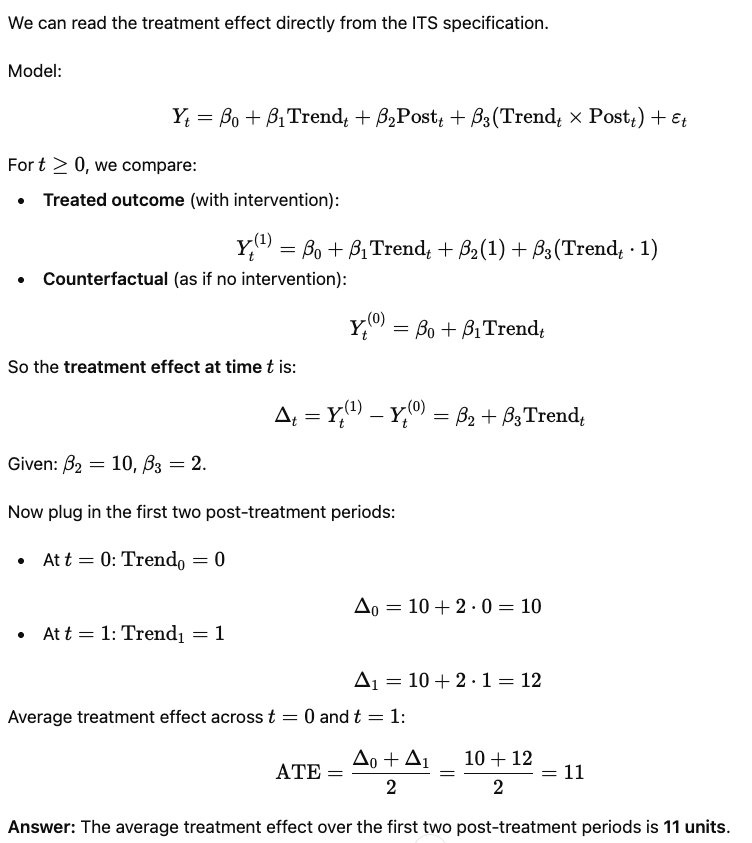